In [2]:
import mysql.connector

In [3]:
import pandas as pd
import numpy as np
import psycopg2
from dotenv import load_dotenv
import mysql.connector
import matplotlib.pyplot as plt


In [4]:
from dotenv import load_dotenv
import os
import psycopg2

load_dotenv()

conn = psycopg2.connect(
    host=os.getenv('POSTGRES_HOST'),
    database=os.getenv('POSTGRES_DATABASE'),
    user=os.getenv('POSTGRES_USER'),
    password=os.getenv('POSTGRES_PASSWORD'),
    port=os.getenv('POSTGRES_PORT')
)

cursor = conn.cursor()
print('Conexão estabelecida com sucesso!')

Conexão estabelecida com sucesso!


In [5]:
conn_mysql = mysql.connector.connect(
    host=os.getenv('MYSQL_HOST'),
    database=os.getenv('MYSQL_DATABASE'),
    user=os.getenv('MYSQL_USER'),
    password=os.getenv('MYSQL_PASSWORD')
)

cursor_mysql = conn_mysql.cursor()
print('Conexão MySql estabelecida com sucesso!')

Conexão MySql estabelecida com sucesso!


In [6]:
query = """
SELECT id_venda, cod_produto, nome_produto, categoria_produto, segmento_produto,
marca_produto, cod_vendedor, nome_vendedor, cod_loja, cidade_loja, estado_loja, data_venda, valor_venda 
from datadt_curso_python.vendas
"""
df = pd.read_sql(query, conn_mysql)
df

C:\Users\Nara&Jean\AppData\Local\Temp\ipykernel_24476\4014228727.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn_mysql)


,id_venda,cod_produto,nome_produto,categoria_produto,segmento_produto,marca_produto,cod_vendedor,nome_vendedor,cod_loja,cidade_loja,estado_loja,data_venda,valor_venda
0,1,SKU-0000001,LG K10 TV Power,Celulares,Corporativo,LG,1009,Ana Teixeira,SP8821,São Paulo,São Paulo,2012-10-04,679.00
1,2,SKU-0000002,Geladeira Duplex,Eletrodomésticos,Doméstico,Brastemp,1006,Josias Silva,SP8821,São Paulo,São Paulo,2012-01-01,832.00
2,3,SKU-0000003,Lavadora 11 Kg,Eletrodomésticos,Doméstico,Brastemp,1006,Josias Silva,SP8821,São Paulo,São Paulo,2012-02-02,790.00
3,4,SKU-0000004,Lavadora 11 Kg,Eletrodomésticos,Doméstico,Brastemp,1003,Mateus Gonçalves,SP8821,São Paulo,São Paulo,2012-03-03,765.32
4,5,SKU-0000005,Lavadora 11 Kg,Eletrodomésticos,Doméstico,Electrolux,1004,Artur Moreira,SP8821,São Paulo,São Paulo,2012-04-04,459.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,453,SKU-0000453,Geladeira Duplex,Eletrodomésticos,Doméstico,Brastemp,1002,André Pereira,R1295,Rio de Janeiro,Rio de Janeiro,2015-09-23,1234.00
453,454,SKU-0000454,Geladeira Duplex,Eletrodomésticos,Doméstico,Brastemp,1002,André Pereira,R1295,Rio de Janeiro,Rio de Janeiro,2015-10-24,1234.00
454,455,SKU-0000455,Morotola Moto G5,Celulares,Doméstico,Motorola,1008,Aline Sutter,R1295,Rio de Janeiro,Rio de Janeiro,2015-11-25,1230.00
455,456,SKU-0000456,Geladeira Duplex,Eletrodomésticos,Doméstico,Brastemp,1002,André Pereira,R1295,Rio de Janeiro,Rio de Janeiro,2015-11-26,1234.00


In [ ]:
query_pg = """
SELECT 'Empresa 02' as empresa, 
date_part('Year', data_venda) as ano, 
sum(valor) as total_vendas
FROM vendas.nota_fiscal nf
GROUP BY date_part('Year', data_venda)
"""

df_pg = pd.read_sql(query_pg, conn)
df_pg

C:\Users\Nara&Jean\AppData\Local\Temp\ipykernel_24476\190051850.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pg = pd.read_sql(query_pg, conn)


,empresa,ano,total_vendas
0,Empresa 02,2015.0,28167840.0
1,Empresa 02,2016.0,29348852.0
2,Empresa 02,2017.0,31045856.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_venda           457 non-null    int64  
 1   cod_produto        457 non-null    str    
 2   nome_produto       457 non-null    str    
 3   categoria_produto  457 non-null    str    
 4   segmento_produto   457 non-null    str    
 5   marca_produto      457 non-null    str    
 6   cod_vendedor       457 non-null    int64  
 7   nome_vendedor      457 non-null    str    
 8   cod_loja           457 non-null    str    
 9   cidade_loja        457 non-null    str    
 10  estado_loja        457 non-null    str    
 11  data_venda         457 non-null    object 
 12  valor_venda        457 non-null    float64
dtypes: float64(1), int64(2), object(1), str(9)
memory usage: 46.5+ KB


In [9]:
df_pg.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   empresa       3 non-null      str    
 1   ano           3 non-null      float64
 2   total_vendas  3 non-null      float64
dtypes: float64(2), str(1)
memory usage: 204.0 bytes


In [10]:
# Convertendo a coluna data_venda para datetime
df['data_venda'] = pd.to_datetime(df['data_venda'])

In [11]:
# Extraindo o ano da data de venda
df['ano'] = df['data_venda'].dt.year
df


,id_venda,cod_produto,nome_produto,categoria_produto,segmento_produto,marca_produto,cod_vendedor,nome_vendedor,cod_loja,cidade_loja,estado_loja,data_venda,valor_venda,ano
0,1,SKU-0000001,LG K10 TV Power,Celulares,Corporativo,LG,1009,Ana Teixeira,SP8821,São Paulo,São Paulo,2012-10-04,679.00,2012
1,2,SKU-0000002,Geladeira Duplex,Eletrodomésticos,Doméstico,Brastemp,1006,Josias Silva,SP8821,São Paulo,São Paulo,2012-01-01,832.00,2012
2,3,SKU-0000003,Lavadora 11 Kg,Eletrodomésticos,Doméstico,Brastemp,1006,Josias Silva,SP8821,São Paulo,São Paulo,2012-02-02,790.00,2012
3,4,SKU-0000004,Lavadora 11 Kg,Eletrodomésticos,Doméstico,Brastemp,1003,Mateus Gonçalves,SP8821,São Paulo,São Paulo,2012-03-03,765.32,2012
4,5,SKU-0000005,Lavadora 11 Kg,Eletrodomésticos,Doméstico,Electrolux,1004,Artur Moreira,SP8821,São Paulo,São Paulo,2012-04-04,459.89,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,453,SKU-0000453,Geladeira Duplex,Eletrodomésticos,Doméstico,Brastemp,1002,André Pereira,R1295,Rio de Janeiro,Rio de Janeiro,2015-09-23,1234.00,2015
453,454,SKU-0000454,Geladeira Duplex,Eletrodomésticos,Doméstico,Brastemp,1002,André Pereira,R1295,Rio de Janeiro,Rio de Janeiro,2015-10-24,1234.00,2015
454,455,SKU-0000455,Morotola Moto G5,Celulares,Doméstico,Motorola,1008,Aline Sutter,R1295,Rio de Janeiro,Rio de Janeiro,2015-11-25,1230.00,2015
455,456,SKU-0000456,Geladeira Duplex,Eletrodomésticos,Doméstico,Brastemp,1002,André Pereira,R1295,Rio de Janeiro,Rio de Janeiro,2015-11-26,1234.00,2015


In [ ]:
# Agrupando por ano e somando os valores de venda
df_vendas_por_ano = df.groupby('ano')['valor_venda'].sum().reset_index()
df_vendas_por_ano

,ano,valor_venda
0,2012,37503.74
1,2013,93418.56
2,2014,63322.02
3,2015,166836.79


In [13]:
# Renomeando a coluna para 'valor_total'
df_vendas_por_ano = df_vendas_por_ano.rename(columns={'valor_venda': 'total_vendas'})

In [14]:
# Adicionando coluna empresa
df_vendas_por_ano['empresa'] = 'Empresa 01'
df_vendas_por_ano

,ano,total_vendas,empresa
0,2012,37503.74,Empresa 01
1,2013,93418.56,Empresa 01
2,2014,63322.02,Empresa 01
3,2015,166836.79,Empresa 01


In [15]:
df_pg['ano'] = df_pg['ano'].astype(int)
df_pg

,empresa,ano,total_vendas
0,Empresa 02,2015,28167840.0
1,Empresa 02,2016,29348852.0
2,Empresa 02,2017,31045856.0


In [16]:
# União dos DataFrames
df_uniao = pd.concat([df_vendas_por_ano, df_pg], ignore_index=True)
df_uniao

,ano,total_vendas,empresa
0,2012,37503.74,Empresa 01
1,2013,93418.56,Empresa 01
2,2014,63322.02,Empresa 01
3,2015,166836.79,Empresa 01
4,2015,28167840.00,Empresa 02
5,2016,29348852.00,Empresa 02
6,2017,31045856.00,Empresa 02


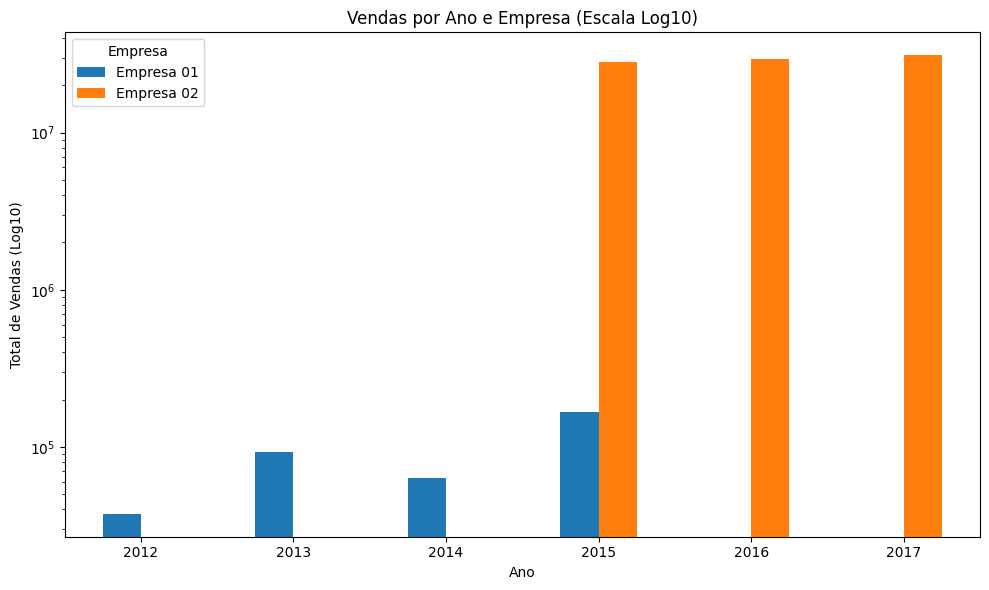

    ano  total_vendas     empresa
0  2012      37503.74  Empresa 01
1  2013      93418.56  Empresa 01
2  2014      63322.02  Empresa 01
3  2015     166836.79  Empresa 01
4  2015   28167840.00  Empresa 02
5  2016   29348852.00  Empresa 02
6  2017   31045856.00  Empresa 02


In [22]:
df_pivot = df_uniao.pivot(index='ano', columns='empresa', values='total_vendas')
df_pivot.plot(kind='bar', figsize=(10, 6), logy=True)
plt.title('Vendas por Ano e Empresa (Escala Log10)')
plt.xlabel('Ano')
plt.ylabel('Total de Vendas (Log10)')
plt.xticks(rotation=0)
plt.legend(title='Empresa')
plt.tight_layout()
plt.show()

print(df_uniao)

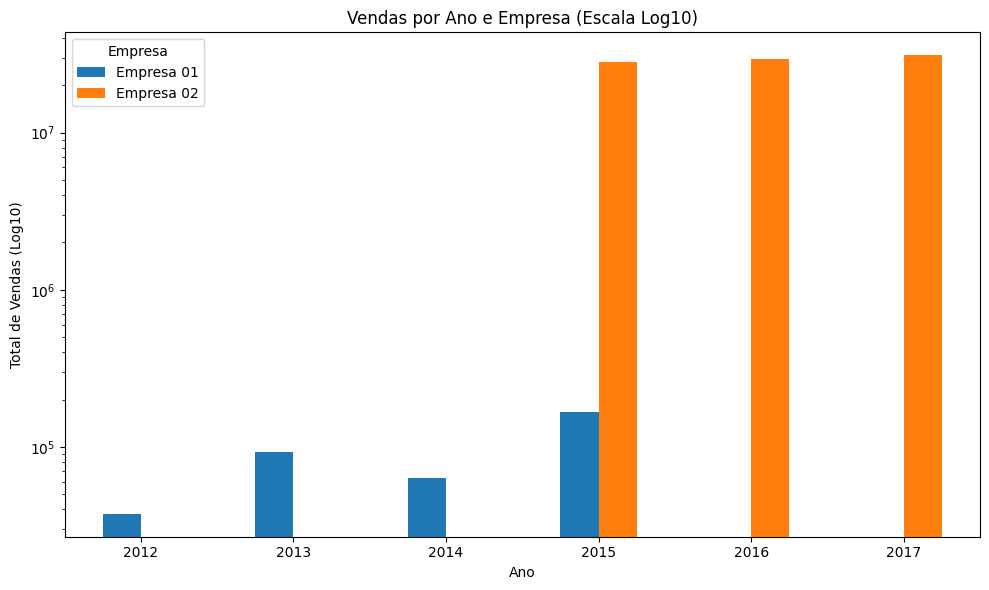

Gráfico salvo como vendas_por_empresa.png


In [30]:
import matplotlib.pyplot as plt

df_pivot = df_uniao.pivot(
    index='ano',
    columns='empresa',
    values='total_vendas'
)

df_pivot.plot(kind='bar', figsize=(10, 6), logy=True)

plt.title('Vendas por Ano e Empresa (Escala Log10)')
plt.xlabel('Ano')
plt.ylabel('Total de Vendas (Log10)')
plt.xticks(rotation=0)
plt.legend(title='Empresa')
plt.tight_layout()

plt.savefig('vendas_por_empresa.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo como vendas_por_empresa.png')

In [31]:
# Fechar cursores e conexões
cursor.close()
cursor_mysql.close()
conn.close()
conn_mysql.close()
print('Conexões fechadas com sucesso!')


Conexões fechadas com sucesso!
